<a href="https://colab.research.google.com/github/jcmachicao/knowledge_engineering/blob/main/U2__rdflib_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdflib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 569.0/569.0 kB 5.4 MB/s eta 0:00:00


In [ ]:
from rdflib import Graph, Namespace, RDF, RDFS, OWL, URIRef, Literal

# Creamos un grafo RDF
g = Graph()

# Definimos un espacio de nombres (namespace) para nuestra ontología
EX = Namespace("http://example.org/compra#")

# Añadimos prefijo al grafo
g.bind("ex", EX)

In [ ]:
# --- Clases ---
g.add((EX.Cliente, RDF.type, OWL.Class))
g.add((EX.Pedido, RDF.type, OWL.Class))
g.add((EX.Producto, RDF.type, OWL.Class))
g.add((EX.Pago, RDF.type, OWL.Class))

<Graph identifier=N95a2fb3c0eb14d1b845439f36e9e5f2f (<class 'rdflib.graph.Graph'>)>

In [ ]:
# --- Propiedades (relaciones) ---
g.add((EX.realiza, RDF.type, OWL.ObjectProperty))
g.add((EX.contiene, RDF.type, OWL.ObjectProperty))
g.add((EX.tiene, RDF.type, OWL.ObjectProperty))
g.add((EX.asociado_a, RDF.type, OWL.ObjectProperty))

<Graph identifier=N95a2fb3c0eb14d1b845439f36e9e5f2f (<class 'rdflib.graph.Graph'>)>

In [ ]:
# --- Dominio y rango (semántica de las relaciones) ---
g.add((EX.realiza, RDFS.domain, EX.Cliente))
g.add((EX.realiza, RDFS.range, EX.Pedido))

g.add((EX.contiene, RDFS.domain, EX.Pedido))
g.add((EX.contiene, RDFS.range, EX.Producto))

g.add((EX.tiene, RDFS.domain, EX.Pedido))
g.add((EX.tiene, RDFS.range, EX.Pago))

g.add((EX.asociado_a, RDFS.domain, EX.Pago))
g.add((EX.asociado_a, RDFS.range, EX.Pedido))

<Graph identifier=N95a2fb3c0eb14d1b845439f36e9e5f2f (<class 'rdflib.graph.Graph'>)>

In [ ]:
# --- Instancias (ejemplos concretos) ---
g.add((EX.Juan, RDF.type, EX.Cliente))
g.add((EX.Pedido1, RDF.type, EX.Pedido))
g.add((EX.ProductoA, RDF.type, EX.Producto))
g.add((EX.Pago1, RDF.type, EX.Pago))

g.add((EX.Juan, EX.realiza, EX.Pedido1))
g.add((EX.Pedido1, EX.contiene, EX.ProductoA))
g.add((EX.Pedido1, EX.tiene, EX.Pago1))
g.add((EX.Pago1, EX.asociado_a, EX.Pedido1))

<Graph identifier=N95a2fb3c0eb14d1b845439f36e9e5f2f (<class 'rdflib.graph.Graph'>)>

In [ ]:
# --- Serializamos (guardamos o mostramos) ---
print(g.serialize(format="turtle"))

@prefix ex: <http://example.org/compra#> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .

ex:Juan a ex:Cliente ;
    ex:realiza ex:Pedido1 .

ex:asociado_a a owl:ObjectProperty ;
    rdfs:domain ex:Pago ;
    rdfs:range ex:Pedido .

ex:contiene a owl:ObjectProperty ;
    rdfs:domain ex:Pedido ;
    rdfs:range ex:Producto .

ex:realiza a owl:ObjectProperty ;
    rdfs:domain ex:Cliente ;
    rdfs:range ex:Pedido .

ex:tiene a owl:ObjectProperty ;
    rdfs:domain ex:Pedido ;
    rdfs:range ex:Pago .

ex:Pago1 a ex:Pago ;
    ex:asociado_a ex:Pedido1 .

ex:ProductoA a ex:Producto .

ex:Cliente a owl:Class .

ex:Pedido1 a ex:Pedido ;
    ex:contiene ex:ProductoA ;
    ex:tiene ex:Pago1 .

ex:Producto a owl:Class .

ex:Pago a owl:Class .

ex:Pedido a owl:Class .




In [ ]:
from rdflib import Graph, Namespace, RDF, OWL, RDFS
import networkx as nx
import matplotlib.pyplot as plt

# --- 1. Crear grafo RDF ---
g = Graph()
EX = Namespace("http://example.org/compra#")
g.bind("ex", EX)

# --- Clases ---
for cls in ["Cliente", "Pedido", "Producto", "Pago"]:
    g.add((EX[cls], RDF.type, OWL.Class))

# --- Propiedades ---
relaciones = {
    "realiza": ("Cliente", "Pedido"),
    "contiene": ("Pedido", "Producto"),
    "tiene": ("Pedido", "Pago"),
    "asociado_a": ("Pago", "Pedido")
}

for prop, (dom, ran) in relaciones.items():
    g.add((EX[prop], RDF.type, OWL.ObjectProperty))
    g.add((EX[prop], RDFS.domain, EX[dom]))
    g.add((EX[prop], RDFS.range, EX[ran]))

# --- Instancias ---
instancias = [
    (EX.Juan, RDF.type, EX.Cliente),
    (EX.Pedido1, RDF.type, EX.Pedido),
    (EX.ProductoA, RDF.type, EX.Producto),
    (EX.Pago1, RDF.type, EX.Pago),
    (EX.Juan, EX.realiza, EX.Pedido1),
    (EX.Pedido1, EX.contiene, EX.ProductoA),
    (EX.Pedido1, EX.tiene, EX.Pago1),
    (EX.Pago1, EX.asociado_a, EX.Pedido1)
]

for s, p, o in instancias:
    g.add((s, p, o))

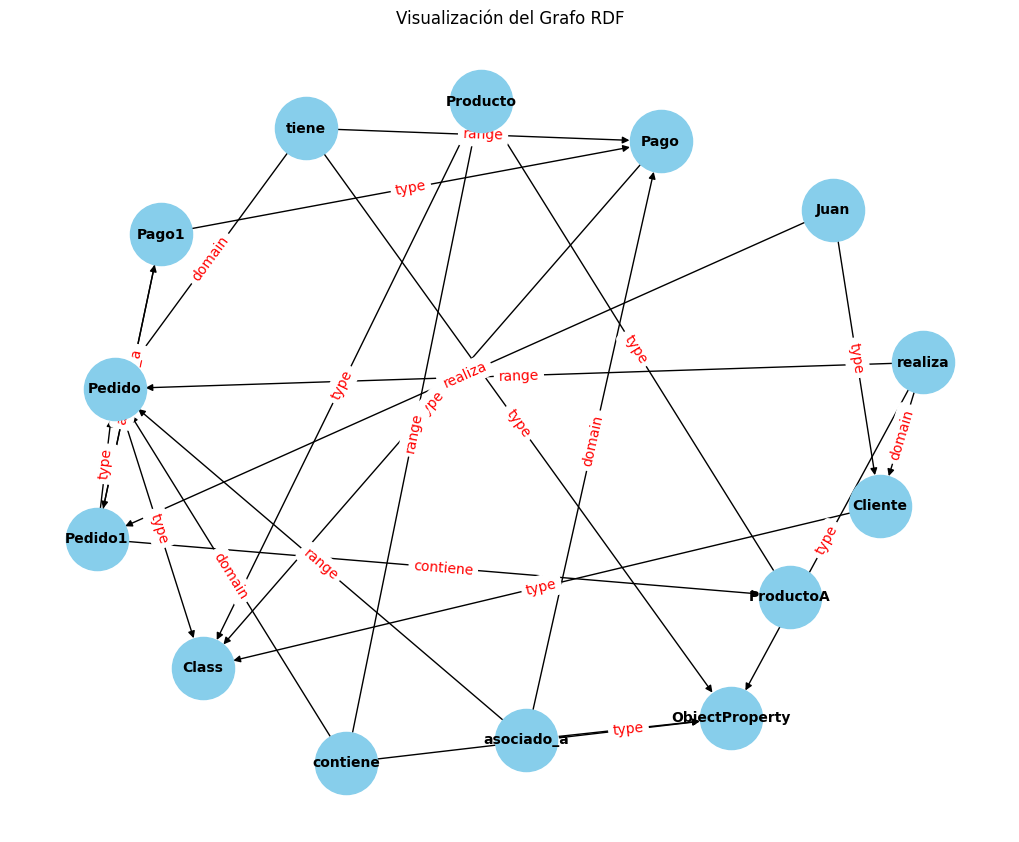

In [ ]:
# --- Convertir grafo RDF a grafo NetworkX ---
G = nx.DiGraph()

for s, p, o in g:
    # Usamos los fragmentos de URI como nombres de nodo
    s_label = s.fragment if s.fragment else str(s)
    p_label = p.fragment if p.fragment else str(p)
    o_label = o.fragment if o.fragment else str(o)
    G.add_node(s_label)
    G.add_node(o_label)
    G.add_edge(s_label, o_label, label=p_label)

# --- Visualizar el grafo NetworkX ---
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=3)  # Puedes probar otros layouts como nx.circular_layout, nx.shell_layout, etc.
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', font_size=10, font_weight='bold')
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'label'), font_color='red')
plt.title("Visualización del Grafo RDF")
plt.show()